# Ratios and Sediment Concentration Final tunning

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
#from Calculation_functions_V2_NIBI import proportions_from_filename, metrics_table

In [2]:
values_cores = np.array([711, 1810, 12700, 1120, 927, 778, 347]) # pg / g
NSoG = values_cores[0]
SSoGa_0 = values_cores[4]
SSoGa_1 = values_cores[6]
IPlume_0 = values_cores[2]
IPlume_1 = values_cores[3]
HWSound = values_cores[1]
SSoGb = values_cores[5]
#
obs = [NSoG, SSoGa_0, SSoGa_1, SSoGb, IPlume_0, IPlume_1, HWSound]
#
obsi = obs / np.sum(values_cores)

Function just for the necessary metrics

In [3]:
def metrics(filename):
    import Region_functions_V3_NIBI
    polygon_dict = Region_functions_V3_NIBI.polygon_definition(filename, time_step = 'day')
    status_vertical_N1 = Region_functions_V3_NIBI.vertical_status_profiles(polygon_dict['N1'], 80)
    status_vertical_S1 = Region_functions_V3_NIBI.vertical_status_profiles(polygon_dict['S1'], 80)
    volumes_regions_depths = Region_functions_V3_NIBI.volume_by_depth_all_regions(polygon_dict)
#
    def interpolate_volume_profile(volume_profile, number_of_depths):
        # Get the existing depth coordinate values (z-levels mapped to actual depth)
        depth_vals = volume_profile['depth'].values
        volume_vals = volume_profile.values

        # Filter out NaNs
        valid = ~np.isnan(depth_vals) & ~np.isnan(volume_vals)
        depth_vals = depth_vals[valid]
        volume_vals = volume_vals[valid]

        # Define new depth bins (higher resolution)
        new_depths = np.linspace(depth_vals.min(), depth_vals.max(), number_of_depths)

        # Interpolate depths
        interp_volume_vals = np.interp(new_depths, depth_vals, volume_vals)
        #
        interpolated_volume = xr.DataArray(
            interp_volume_vals,
            coords={'depth': new_depths},
            dims='depth',
            name='volume'
        )

        return interpolated_volume, new_depths
    ##################
    depth_bins_regions = 81
    #####
    volume_N1, depths_N1 = interpolate_volume_profile(volumes_regions_depths['N1'], depth_bins_regions)
    volume_N2, depths_N2 = interpolate_volume_profile(volumes_regions_depths['N2'], depth_bins_regions)
    volume_S1, depths_S1 = interpolate_volume_profile(volumes_regions_depths['S1'], depth_bins_regions)
    volume_SP, depths_SP = interpolate_volume_profile(volumes_regions_depths['SP'], depth_bins_regions)
    volume_HW1, depths_HW1 = interpolate_volume_profile(volumes_regions_depths['HW1'], depth_bins_regions)
    volume_S2, depths_S2 = interpolate_volume_profile(volumes_regions_depths['S2'], depth_bins_regions)

    #################
    status_vertical_N1 = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['N1'], depth_bin_edges=depths_N1)
    status_vertical_N2 = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['N2'], depth_bin_edges=depths_N2)
    status_vertical_S1 = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['S1'], depth_bin_edges=depths_S1)
    status_vertical_SP = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['SP'], depth_bin_edges=depths_SP)
    status_vertical_HW1 = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['HW1'], depth_bin_edges=depths_HW1)
    status_vertical_S2 = Region_functions_V3_NIBI.vertical_status_profiles_V2(polygon_dict['S2'], depth_bin_edges=depths_S2)
    ### Ratio N1-S1 ###
    # JUST COLLOIDAL
    #
    data = xr.open_zarr(filename)
    data = data.isel(obs=slice(-120,None))
    volumes_regions, regions_names = Region_functions_V3_NIBI.volumes_50m_bottom()
    volume_S1 = volumes_regions[4]# + volumes_regions[5]
    volume_N1 = volumes_regions[0]
        
    counts_S1 = Region_functions_V3_NIBI.polygon_definition_data_colloidal(data, Region_functions_V3_NIBI.polygon_lon_lat_S1)
    counts_N1 = Region_functions_V3_NIBI.polygon_definition_data_colloidal(data, Region_functions_V3_NIBI.polygon_lon_lat_N1)

    sum_concentration_S1 = np.sum(counts_S1) / volume_S1
    sum_concentration_N1 = np.sum(counts_N1) / volume_N1

    ratio_N1_S1 = sum_concentration_N1 / sum_concentration_S1
  
    ###############################################################################
    ### Proportions INFO ###
    #
    #proportions = proportions_from_filename(filename)
    #
    ### RATIO M/C WATER ###
    def vertical_ratios(status_vertical):
        numerator = status_vertical['Particles Status 3'].astype(float)
        denominator = (
            status_vertical['Particles Status 3'] +
            status_vertical['Particles Status 2'] +
            status_vertical['Particles Status 1']
        ).astype(float)
        
        mask = (numerator == 0) | (denominator == 0)
        
        particulate_ratio = (numerator / denominator).mask(mask) * 100
        dissolved_ratio = 100 - particulate_ratio

        df = pd.DataFrame({
            'Depth': status_vertical['Avg. Depth'].values,
            'Dissolved (%)': dissolved_ratio.values,
            'Particulate (%)': particulate_ratio.values
        })

        return df
    N1_model, S1_model, SP_model = [
    vertical_ratios(status_vertical_N1), vertical_ratios(status_vertical_S1), vertical_ratios(status_vertical_SP)]
    #
    median_N1 = (N1_model['Particulate (%)'] / N1_model['Dissolved (%)']).median()
    median_SP = (SP_model['Particulate (%)'] / SP_model['Dissolved (%)']).median()
    median_S1 = (SP_model['Particulate (%)'] / SP_model['Dissolved (%)']).median()
    #
    model_ratios = [median_N1, median_SP, median_S1]
    #
    ratio_MC_Water = np.nanmedian(model_ratios)
    #
    ### RATIO M/C WATER ###
    #
    values_cores = np.array([711, 1810, 12700, 1120, 927, 778, 347]) # pg / g
    NSoG = values_cores[0]
    SSoGa_0 = values_cores[4]
    SSoGa_1 = values_cores[6]
    IPlume_0 = values_cores[2]
    IPlume_1 = values_cores[3]
    HWSound = values_cores[1]
    SSoGb = values_cores[5]
    r_model = ['NSoG', 'SSoG', 'IPlume', 'HWSound']

    #
    volumes_regions, _ = Region_functions_V3_NIBI.volumes()
    NSoG_OP = status_vertical_N2['Particles Status 11'].sum() + status_vertical_N2['Particles Status 12'].sum() + status_vertical_N2['Particles Status 13'].sum() 
    SSoG_OP = status_vertical_S2['Particles Status 11'].sum() + status_vertical_S2['Particles Status 12'].sum() + status_vertical_S2['Particles Status 13'].sum() 
    IPlume_OP = status_vertical_SP['Particles Status 11'].sum() + status_vertical_SP['Particles Status 12'].sum() + status_vertical_SP['Particles Status 13'].sum() 
    HWSound_OP = status_vertical_HW1['Particles Status 11'].sum() + status_vertical_HW1['Particles Status 12'].sum() + status_vertical_HW1['Particles Status 13'].sum() 
    #
    obs = [NSoG, SSoGa_0, SSoGa_1, SSoGb, IPlume_0, IPlume_1, HWSound]
    #
    OP_model = [NSoG_OP / volumes_regions[1], SSoG_OP / volumes_regions[8], IPlume_OP / volumes_regions[5], HWSound_OP / volumes_regions[6]]
    #
    obsi = obs / np.sum(values_cores)
    OP_modeli = OP_model / np.sum(OP_model)
    #
    #OP_modeli = OP_model / np.nansum(OP_model)    
    #Concentration_Sediment = np.nanmedian(OP_modeli)
    #
    ### Simulation Info ###
    #
    #data = xr.open_dataset(filename, engine='zarr')
    data_water = data.where((data.status > 0) & (data.status < 4))
    data_sediment = data.where(data.status > 10)
    #
    depth_mean_water = data_water.z.mean().values
    depth_mean_sediment = data_sediment.z.mean().values
    ###
    ##   
    #
    df = pd.DataFrame([{
        'Simulation Label': 'Simulation',
        'M/C': ratio_MC_Water,
        'NSoG/SSoG': ratio_N1_S1,
        'HS/SSoG': np.nan,
        'Out JdF (%)': np.nan,
        'Out Js (%)': np.nan,
        'Total Colloidal W. C. (%)': np.nan,
        'W. C.': depth_mean_water,
        'Sed.': depth_mean_sediment
    }])    

    df_sed = pd.DataFrame([{
        r_model[0]: OP_modeli[0],
        r_model[1]: OP_modeli[1],
        r_model[2]: OP_modeli[2],
        r_model[3]: OP_modeli[3]
    }])
    return df, df_sed

In [4]:
files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_1_days_tau_0_012.zarr',
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_5_days_tau_0_0075_Pa.zarr',
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_1_days_tau_0_012.zarr',
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_1_days_tau_0_005_Pa.zarr',
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_05_days_tau_0_001_Pa.zarr',
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_ADS_0_01_TAU_0_005_MC_0_2_VEL_H_x1_2.zarr']

In [5]:
data = xr.open_zarr(files[-1])

In [6]:
data.time[0,-1].values

np.datetime64('2007-11-21T18:30:00.000000000')

- option 1 can be good files[1]
- option 4 not good option files[4]
- option 3 not a really good option files[3]
- option 0 could be a good option files[0]
- option 2 not good option files[2]

In [7]:
table_adsorption_v1, sed_conc_adsorption_v1  = metrics(filename = files[-1])
#table_adsorption_v2, sed_conc_adsorption_v2  = metrics(filename = files[1])

#table_adsorption_v2, sed_conc_adsorption_v2  = metrics_table(filename = files[1], plot = False)
#table_adsorption_v3, sed_conc_adsorption_v3  = metrics_table(filename = files[2], plot = False)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/matplotlib/collections.py:200: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  offsets = np.asanyarray(offsets, float)


Text(0.5, 1.0, 'Sediment Concentration')

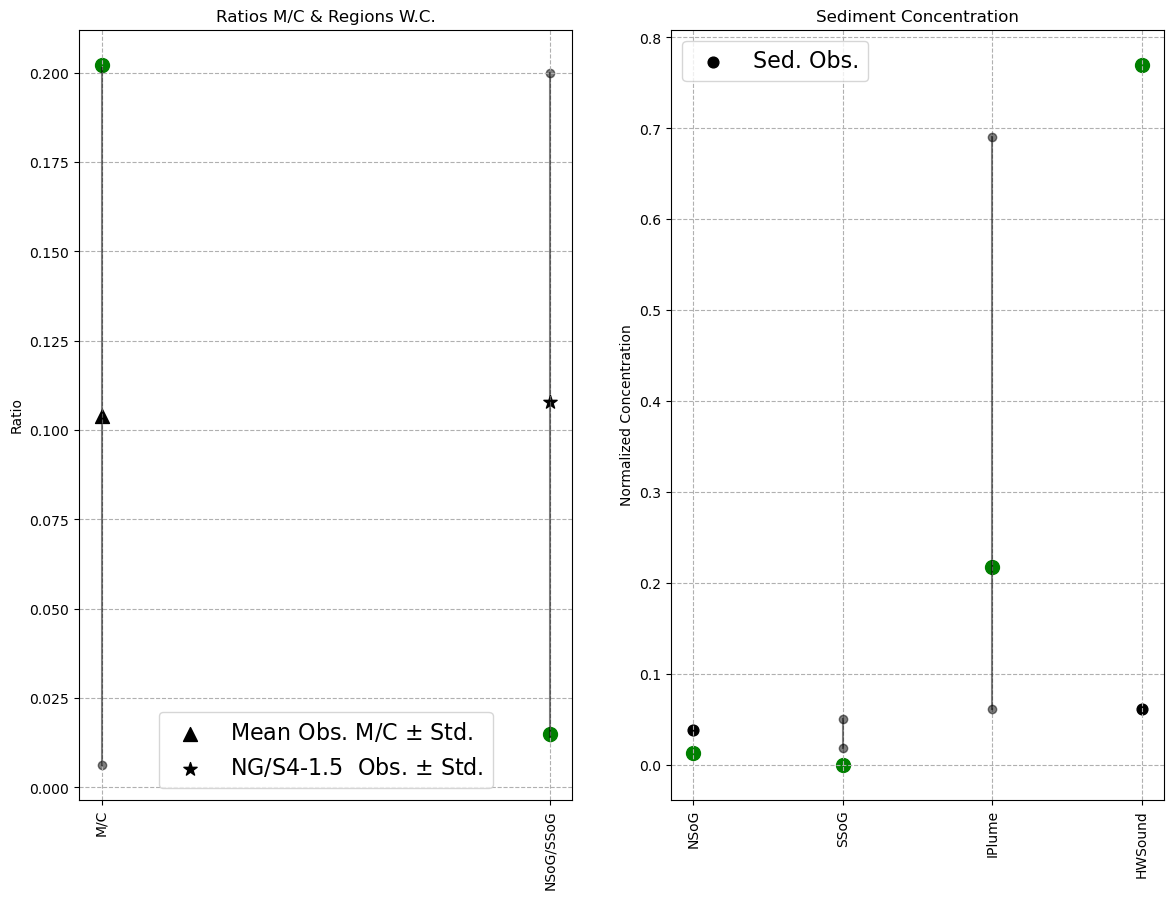

In [8]:
fig, ax = plt.subplots(1,2,figsize = (14,10))
ratios = [0.27, 0.06, 0.012, 0.011, 0.07, 0.2]
#print(np.mean(ratios))
#print(np.mean(ratios) + np.std(ratios))
#print(np.mean(ratios) - np.std(ratios))
ax[0].scatter(table_adsorption_v1.columns[1], np.mean(ratios), c='k', marker = '^', s = 100, label = rf'Mean Obs. M/C $\pm$ Std.')
ax[0].plot([table_adsorption_v1.columns[1], table_adsorption_v1.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], '-k', alpha = .5)
ax[0].scatter([table_adsorption_v1.columns[1], table_adsorption_v1.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], c = 'k', marker = 'o', alpha = .5)
#
ax[0].scatter(table_adsorption_v1.columns[2], 0.108, c='k', marker = '*', s = 100, label = rf'NG/S4-1.5  Obs. $\pm$ Std.')
ax[0].plot([table_adsorption_v1.columns[2], table_adsorption_v1.columns[2]], [0.014, 0.2], '-k', alpha = .5)
ax[0].scatter([table_adsorption_v1.columns[2], table_adsorption_v1.columns[2]], [0.014, 0.2], c = 'k', marker = 'o', alpha = .5)

#
ax[0].scatter(table_adsorption_v1.columns[[1,2,3]], table_adsorption_v1.loc[0].values[[1,2,3]], color='g', s=100)
#ax[0].scatter(table_adsorption_v2.columns[[1,2,3]], table_adsorption_v2.loc[0].values[[1,2,3]], color='b', s=100)
#ax[0].scatter(table_adsorption_v3.columns[[1,2,3]], table_adsorption_v3.loc[0].values[[1,2,3]], color='r', s=100)
ax[0].grid(linestyle='--')
ax[0].tick_params(axis='x', rotation=90)
ax[0].legend(fontsize = 16)
ax[0].set_ylabel('Ratio')
ax[0].set_title('Ratios M/C & Regions W.C.')

#
r_labels = ['NSoG', 'SSoG', 'SSoG', 'SSoG', 'IPlume', 'IPlume', 'HWSound']
ax[1].scatter(sed_conc_adsorption_v1.columns[:], sed_conc_adsorption_v1.loc[0].values[:], color='g', s=100)
#ax[1].scatter(sed_conc_adsorption_v2.columns[:], sed_conc_adsorption_v2.loc[0].values[:], color='b', s=100)
#ax[1].scatter(sed_conc_adsorption_v3.columns[:], sed_conc_adsorption_v3.loc[0].values[:], color='r', s=100)
ax[1].scatter(r_labels[0], obsi[0], c='k', marker = 'o', s = 60, label = 'Sed. Obs.') # Median of normalized obs. concentrations
#ax5.scatter(r_labels[1:3], obsi[1:3], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax[1].plot([r_labels[1], r_labels[1]], [np.min(obsi[1:4]), np.max(obsi[1:4])],'-ok', alpha = .5) # Median of normalized obs. concentrations
#ax5.scatter(r_labels[3:5], obsi[3:5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax[1].plot([r_labels[4], r_labels[5]], [obsi[4], obsi[5]],'-ok', alpha = .5) # Median of normalized obs. concentrations
ax[1].scatter(r_labels[6], obsi[5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations

ax[1].grid(linestyle='--')
ax[1].legend(fontsize = 16)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_ylabel('Normalized Concentration')
#ax5.set_ylim([0.02, 0.06])
ax[1].set_title('Sediment Concentration')

Decision final! Opcion 1 se queda... dentro de los rangos y con una concentracion en S1 que esta dentro de las mas altas!

Final set up for long term run:
- Adsorption = 0.5 days
- Tau = 0.0075 Pa
- MC ratio = 0.2
- Marine Sinking = 132 m/day
- Sewage Sinking = 308 m/day